## Setup
Import necessary packages and define function to load metrics from filepath.

In [5]:
import json
import matplotlib.pyplot as plt
import jax.numpy as jp
import dill

def load_metrics(path):
    with open(path, "rb") as f:
        return dill.load(f)

## Plot metrics

Plot the metrics for proprioceptive and exteroceptive data.

Case 0 Proprioceptive: Mean linear velocity tracking error: 0.051 ± 0.032
Case 0 Proprioceptive: Torso height mean: 0.349, std: 0.004
Case 0 Proprioceptive: Mean angular velocity tracking error: 1.448 ± 0.348
Case 0 Exteroceptive: Mean linear velocity tracking error: 0.038 ± 0.029
Case 0 Exteroceptive: Torso height mean: 0.344, std: 0.004
Case 0 Exteroceptive: Mean angular velocity tracking error: 1.440 ± 0.369


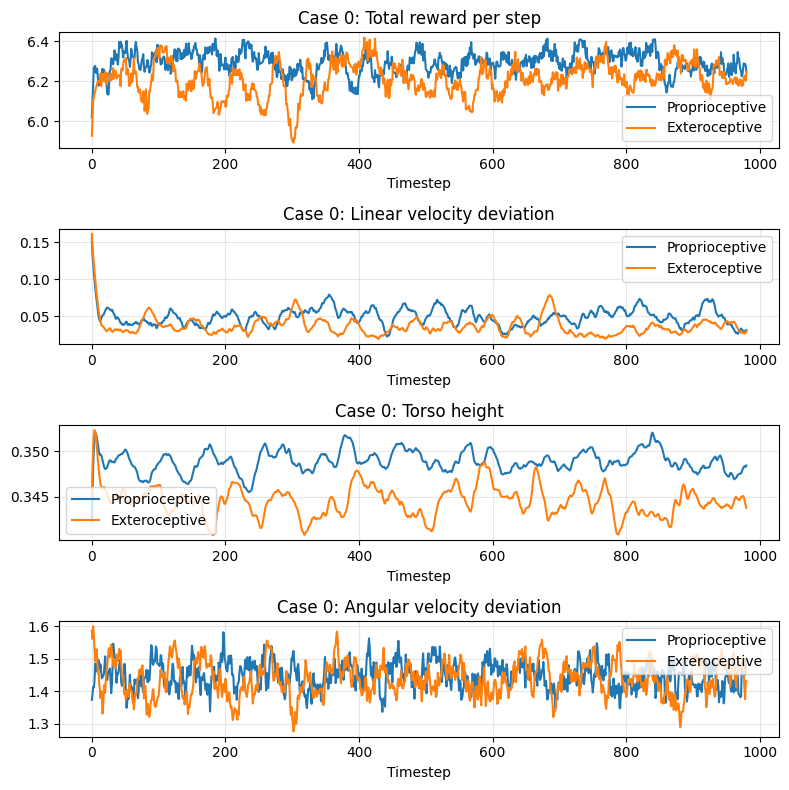

Case 1 Proprioceptive: Mean linear velocity tracking error: 0.931 ± 0.054
Case 1 Proprioceptive: Torso height mean: 0.332, std: 0.036
Case 1 Proprioceptive: Mean angular velocity tracking error: 0.530 ± 0.359
Case 1 Exteroceptive: Mean linear velocity tracking error: 0.764 ± 0.139
Case 1 Exteroceptive: Torso height mean: 0.362, std: 0.036
Case 1 Exteroceptive: Mean angular velocity tracking error: 0.842 ± 0.521


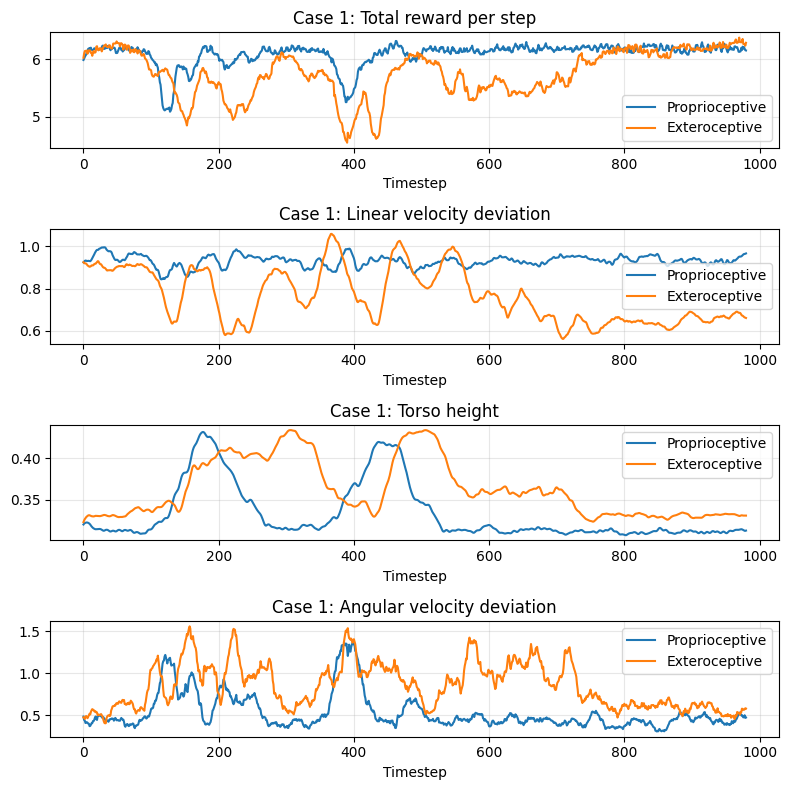

Case 2 Proprioceptive: Mean linear velocity tracking error: 1.888 ± 0.072
Case 2 Proprioceptive: Torso height mean: 0.327, std: 0.027
Case 2 Proprioceptive: Mean angular velocity tracking error: 0.628 ± 0.445
Case 2 Exteroceptive: Mean linear velocity tracking error: 1.548 ± 0.153
Case 2 Exteroceptive: Torso height mean: 0.352, std: 0.029
Case 2 Exteroceptive: Mean angular velocity tracking error: 0.782 ± 0.606


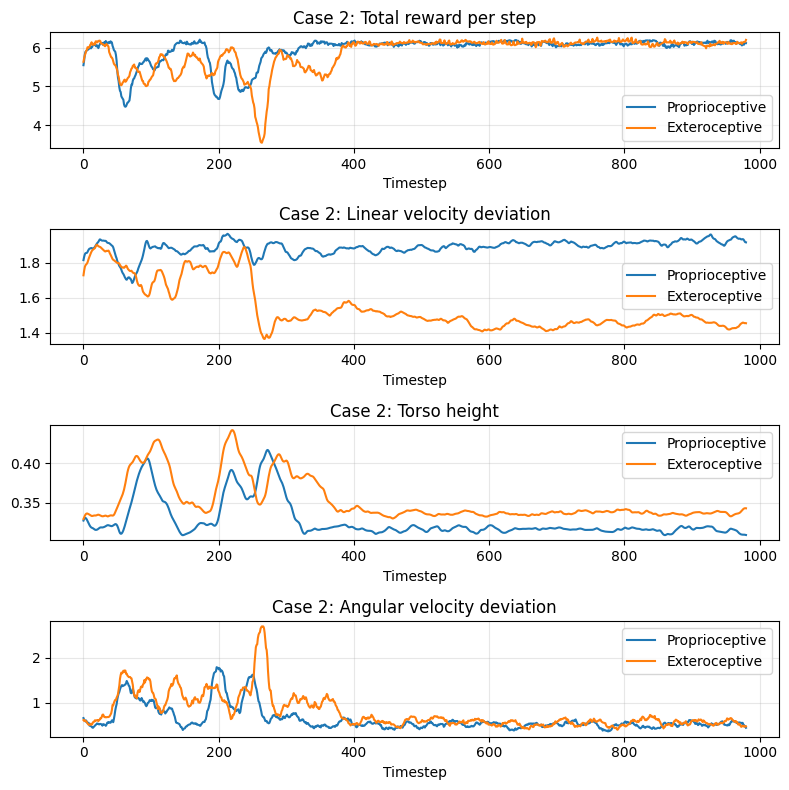

Case 3 Proprioceptive: Mean linear velocity tracking error: 0.775 ± 0.148
Case 3 Proprioceptive: Torso height mean: 0.381, std: 0.038
Case 3 Proprioceptive: Mean angular velocity tracking error: 0.718 ± 0.414
Case 3 Exteroceptive: Mean linear velocity tracking error: 0.934 ± 0.096
Case 3 Exteroceptive: Torso height mean: 0.390, std: 0.044
Case 3 Exteroceptive: Mean angular velocity tracking error: 0.897 ± 0.479


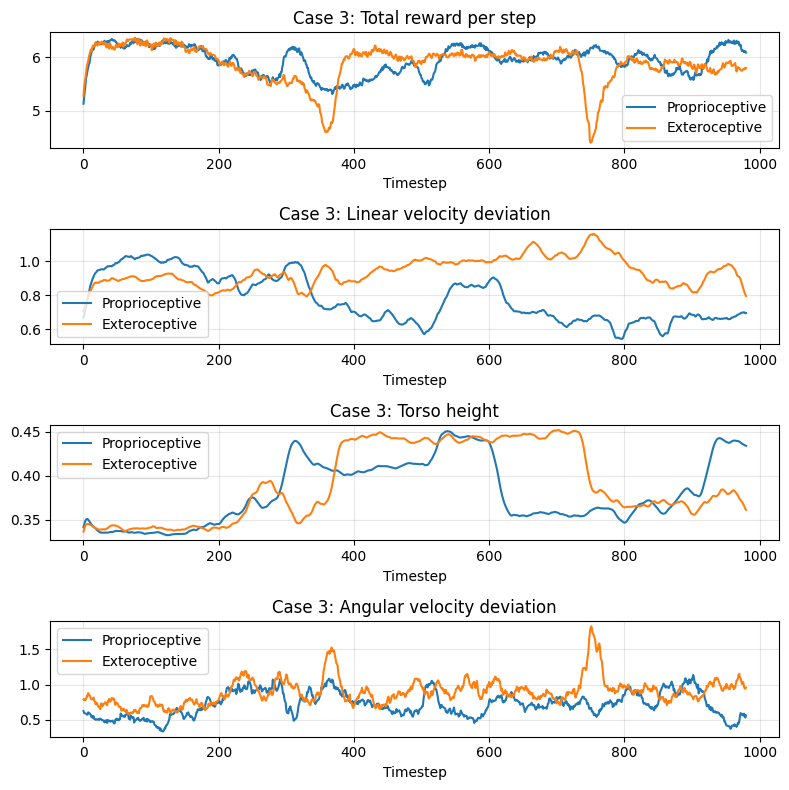

Case 4 Proprioceptive: Mean linear velocity tracking error: 1.783 ± 0.159
Case 4 Proprioceptive: Torso height mean: 0.345, std: 0.029
Case 4 Proprioceptive: Mean angular velocity tracking error: 0.829 ± 0.555
Case 4 Exteroceptive: Mean linear velocity tracking error: 1.489 ± 0.252
Case 4 Exteroceptive: Torso height mean: 0.356, std: 0.026
Case 4 Exteroceptive: Mean angular velocity tracking error: 0.959 ± 0.564


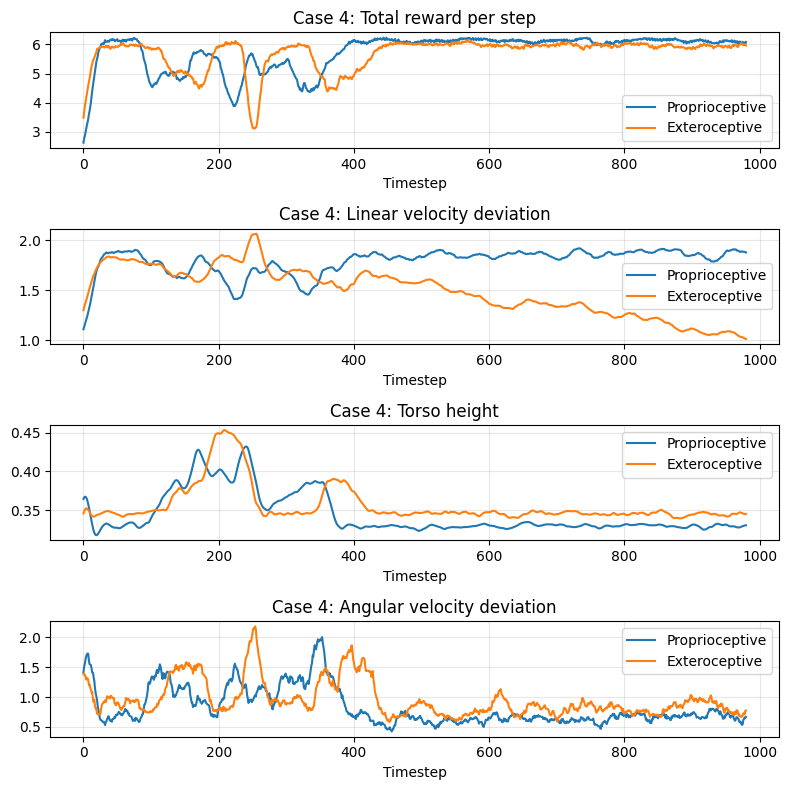

Case 5 Proprioceptive: Mean linear velocity tracking error: 0.714 ± 0.394
Case 5 Proprioceptive: Torso height mean: 0.346, std: 0.036
Case 5 Proprioceptive: Mean angular velocity tracking error: 0.849 ± 0.633
Case 5 Exteroceptive: Mean linear velocity tracking error: 0.823 ± 0.387
Case 5 Exteroceptive: Torso height mean: 0.365, std: 0.036
Case 5 Exteroceptive: Mean angular velocity tracking error: 1.042 ± 0.642


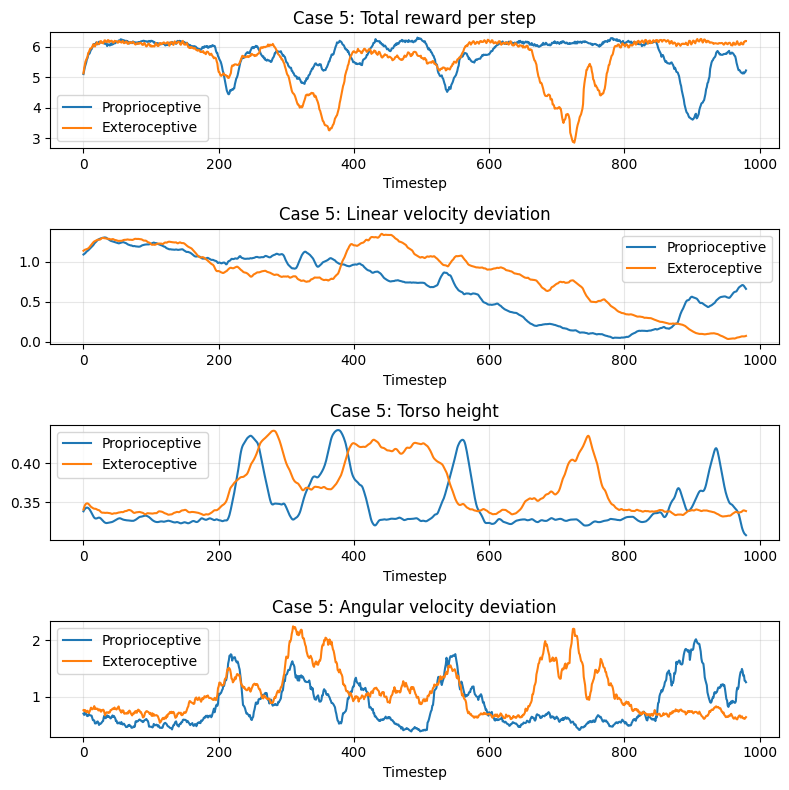

In [6]:
proprio_metrics = load_metrics("metrics/proprioceptive_metrics.dill")
extero_metrics = load_metrics("metrics/exteroceptive_metrics.dill")
student_metrics = load_metrics("metrics/student_metrics.dill")


policies = {
    "Proprioceptive": proprio_metrics,
    "Exteroceptive": extero_metrics,
    "Student": student_metrics,
}

policy_colors = {
    "Proprioceptive": "tab:blue",
    "Exteroceptive": "tab:orange",
    "Student": "tab:green",
}


# NOTE: Change here which to plot
compare = ["Proprioceptive", "Exteroceptive"]
policies = {name: policies[name] for name in compare}

cases = len(proprio_metrics)
window = 20

for i in range(cases):
    fig, axs = plt.subplots(4, 1, figsize=(8, 8))  # new figure each loop

    for policy_name, metric in policies.items():
        smooth_reward = jp.convolve(jp.array(metric[i]["total_reward"]), jp.ones(window)/window, mode='valid')
        axs[0].plot(smooth_reward, label=policy_name, color=policy_colors[policy_name])

        smooth_lin_vel = jp.convolve(jp.array(metric[i]["linear_velocity_deviation"]), jp.ones(window)/window, mode='valid')
        axs[1].plot(smooth_lin_vel, label=policy_name, color=policy_colors.get(policy_name))

        smooth_torso = jp.convolve(jp.array(metric[i]["torso_heights"]), jp.ones(window)/window, mode="valid")
        axs[2].plot(smooth_torso, label=policy_name, color=policy_colors[policy_name])

        smooth_ang_vel = jp.convolve(jp.array(metric[i]["angvel_deviation"]), jp.ones(window)/window, mode="valid")
        axs[3].plot(smooth_ang_vel, label=policy_name, color=policy_colors[policy_name])

        # Get mean and std lin vel error
        mean_error = jp.mean(jp.array(metric[i]["linear_velocity_deviation"]))
        std_error = jp.std(jp.array(metric[i]["linear_velocity_deviation"]))
        print(f"Case {i} {policy_name}: Mean linear velocity tracking error: {mean_error:.3f} ± {std_error:.3f}")

        # Get mean and std torso height
        mean_height = jp.mean(jp.array(metric[i]["torso_heights"]))
        std_height = jp.std(jp.array(metric[i]["torso_heights"]))
        print(f"Case {i} {policy_name}: Torso height mean: {mean_height:.3f}, std: {std_height:.3f}")

        # Get mean and std ang vel error
        mean_ang_error = jp.mean(jp.array(metric[i]["angvel_deviation"]))
        std_ang_error = jp.std(jp.array(metric[i]["angvel_deviation"]))
        print(f"Case {i} {policy_name}: Mean angular velocity tracking error: {mean_ang_error:.3f} ± {std_ang_error:.3f}")

    axs[0].set_title(f"Case {i}: Total reward per step")
    axs[1].set_title(f"Case {i}: Linear velocity deviation")
    axs[2].set_title(f"Case {i}: Torso height")
    axs[3].set_title(f"Case {i}: Angular velocity deviation")
    
    for ax in axs:
        ax.set_xlabel("Timestep")
        ax.grid(alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()